In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from keras.layers import (Dense, Flatten, Reshape, Convolution2D, MaxPooling2D, InputLayer,
                                        ## data augmentation:
                                        Rescaling, RandomRotation, RandomFlip,
                                        ## regularisation:
                                        Dropout) 

from keras.datasets import fashion_mnist

import keras

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

### Data

In [2]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()
X_train.shape

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


(60000, 28, 28)

In [29]:
labels = ['0 T-shirt/top'
        , '1 Trouser'
        , '2 Pullover'
        , '3 Dress'
        , '4 Coat'
        , '5 Sandal'
        , '6 Shirt'
        , '7 Sneaker'
        , '8 Bag'
        , '9 Ankle boot']

### Univariate target

In [30]:
y_series = pd.Series(data=y_train, name='y_train')
group_by_y = y_series.value_counts().sort_index()
group_by_y.index = labels

display(group_by_y)

0 T-shirt/top    6000
1 Trouser        6000
2 Pullover       6000
3 Dress          6000
4 Coat           6000
5 Sandal         6000
6 Shirt          6000
7 Sneaker        6000
8 Bag            6000
9 Ankle boot     6000
Name: count, dtype: int64

In [51]:
y_train

array([9, 0, 0, ..., 3, 0, 5], shape=(60000,), dtype=uint8)

### Preprocessing

In [5]:
X_train = X_train/np.max(X_train,axis=None)
X_test = X_test/np.max(X_test,axis=None)

### CNN model definition with augmentation layers

In [41]:
def get_model(n_class: int, activation: str = 'relu') -> keras.Sequential:

    model = keras.Sequential([
        InputLayer((28,28,)),
        Reshape((28, 28, 1)),

        # --- Data augmentation layers ---
        Rescaling(1./255),
        RandomRotation(0.05),
        RandomFlip("horizontal"),

        # --- CNN layers ---
        Convolution2D(filters=32, kernel_size=3, activation=activation),
        MaxPooling2D(2),

        Convolution2D(filters=64, kernel_size=3, activation=activation),
        MaxPooling2D(2),

        Flatten(),

        Dense(units=128, activation=activation),
        Dense(units=128, activation=activation),
        Dense(units=n_class, activation='softmax')
    ])

    model.compile(tf.keras.optimizers.Adam(),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    return model


def plot_lc(history: dict, metrics: list = ['loss', 'accuracy']) -> None:
    plt.figure(figsize=(20, 8))
    for i, metric in enumerate(metrics):
        plt.subplot(1, 2, i+1)
        plt.title(f'Learning curve for {metric}\n')
        plt.plot(history[metric], label='train')
        plt.plot(history[f'val_{metric}'], label='val')
        plt.xlabel('epochs')
        plt.ylabel(metric)
        plt.legend()
        if metric == 'accuracy':
            plt.ylim(0,1.1)
    plt.show()


def plot_cm_display(y_true: np.array, y_pred: np.array) -> None:
    cm = confusion_matrix(y_true, y_pred)
    
    #plt.figure(figsize=(20, 8))
    #plt.title('Confusion Matrix\n')
    CM = ConfusionMatrixDisplay(cm)
    CM.plot()
    #sns.heatmap(cm, cmap='vlag', annot=True, fmt='d', cbar=False)
    #plt.xlabel('y_pred')
    #plt.ylabel('y_true')
    plt.show()

### Visualizing augmented samples

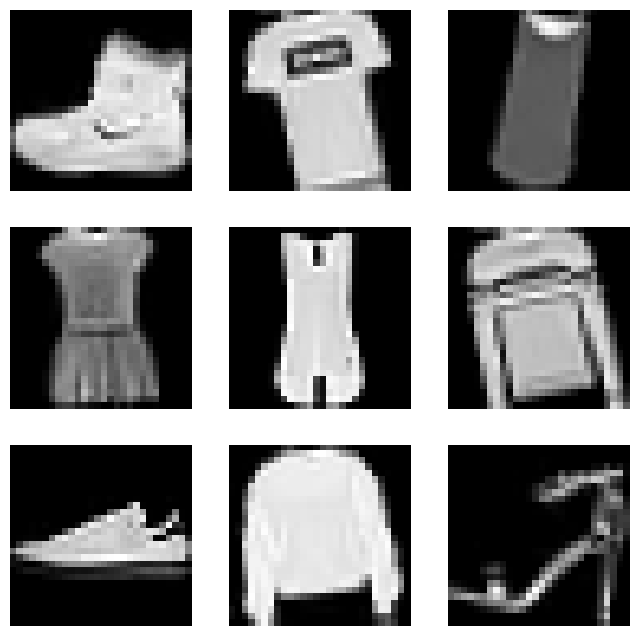

In [ ]:
# Build only the augmentation model
data_augmentation = keras.Sequential([
    Rescaling(1./255),
    RandomRotation(0.05),
    RandomFlip("horizontal"),
])

# Load a few Fashion-MNIST samples
(X_train, _), _ = keras.datasets.fashion_mnist.load_data()
X_train = X_train[..., None]

# Take one batch
images = X_train[:9]

# Apply augmentation
augmented = data_augmentation(images)

# Plot
plt.figure(figsize=(8, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(augmented[i].numpy().squeeze(), cmap="gray")
    plt.axis("off")

plt.show()

### CNN model training

In [32]:
cnn = get_model(10)
cnn.fit(X_train, y_train, validation_split=.2, epochs=7, batch_size=256)

Epoch 1/7
188/188 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - accuracy: 0.3993 - loss: 1.7287 - val_accuracy: 0.5944 - val_loss: 1.0944
Epoch 2/7
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.6003 - loss: 1.1262 - val_accuracy: 0.6797 - val_loss: 0.9205
Epoch 3/7
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.6594 - loss: 0.9547 - val_accuracy: 0.6752 - val_loss: 0.8548
Epoch 4/7
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 31ms/step - accuracy: 0.6841 - loss: 0.8649 - val_accuracy: 0.7175 - val_loss: 0.7725
Epoch 5/7
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.6986 - loss: 0.8067 - val_accuracy: 0.7186 - val_loss: 0.7372
Epoch 6/7
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.7131 - loss: 0.7653 - val_accuracy: 0.7341 - val_loss: 0.7158
Epoch 7/7
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.7251 - loss: 0.7355 - val_accuracy: 0.7400 - val_loss: 0.6826


In [43]:
cnn_2 = get_model(10)
cnn_2.fit(X_train, y_train, validation_split=.15, epochs=10, batch_size=128)

Epoch 1/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.7471 - loss: 0.6947 - val_accuracy: 0.8096 - val_loss: 0.5133
Epoch 2/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.8318 - loss: 0.4601 - val_accuracy: 0.8439 - val_loss: 0.4325
Epoch 3/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.8544 - loss: 0.3963 - val_accuracy: 0.8569 - val_loss: 0.4055
Epoch 4/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.8657 - loss: 0.3671 - val_accuracy: 0.8764 - val_loss: 0.3466
Epoch 5/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.8730 - loss: 0.3425 - val_accuracy: 0.8712 - val_loss: 0.3581
Epoch 6/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.8822 - loss: 0.3205 - val_accuracy: 0.8727 - val_loss: 0.3559
Epoch 7/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.8870 - loss: 0.3077 - val_accuracy: 0.8834 - val_loss: 0.3195
Epoch 8/10
399/399 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.8897 - loss: 0.2945 - val_ac

In [20]:
cnn_3 = get_model(10)
cnn_3.fit(X_train, y_train, validation_split=.12, epochs=8, batch_size=64)

Epoch 1/8
825/825 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.8106 - loss: 0.5158 - val_accuracy: 0.8633 - val_loss: 0.3707
Epoch 2/8
825/825 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8784 - loss: 0.3306 - val_accuracy: 0.8797 - val_loss: 0.3309
Epoch 3/8
825/825 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8965 - loss: 0.2819 - val_accuracy: 0.8925 - val_loss: 0.2892
Epoch 4/8
825/825 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9073 - loss: 0.2495 - val_accuracy: 0.8940 - val_loss: 0.2845
Epoch 5/8
825/825 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9170 - loss: 0.2255 - val_accuracy: 0.9051 - val_loss: 0.2525
Epoch 6/8
825/825 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9240 - loss: 0.2020 - val_accuracy: 0.9051 - val_loss: 0.2586
Epoch 7/8
825/825 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9311 - loss: 0.1827 - val_accuracy: 0.9106 - val_loss: 0.2559
Epoch 8/8
825/825 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.9387 - loss: 0.1628 - val_accuracy:

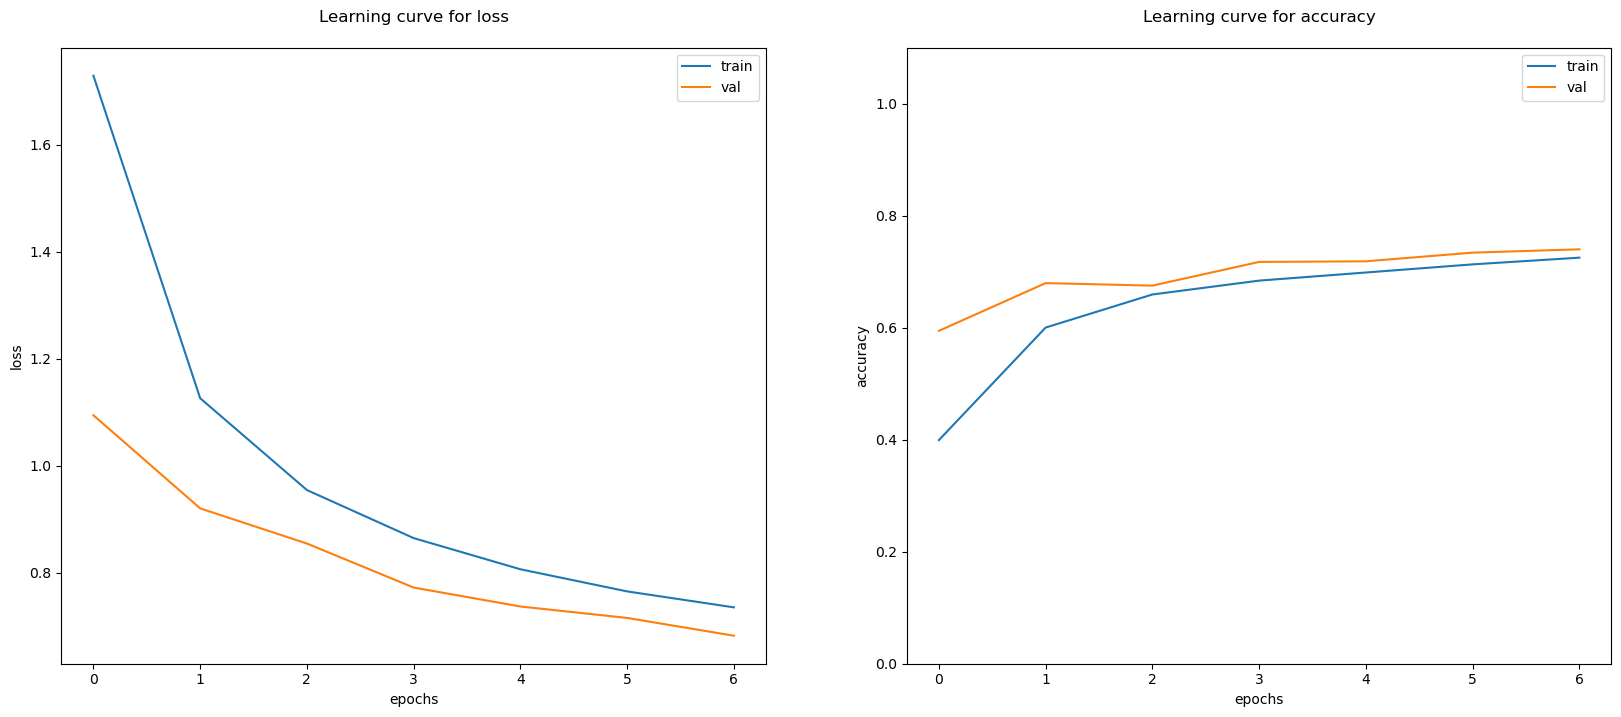

In [33]:
plot_lc(cnn.history.history)

In [34]:
y_pred = np.argmax(cnn.predict(X_test), axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


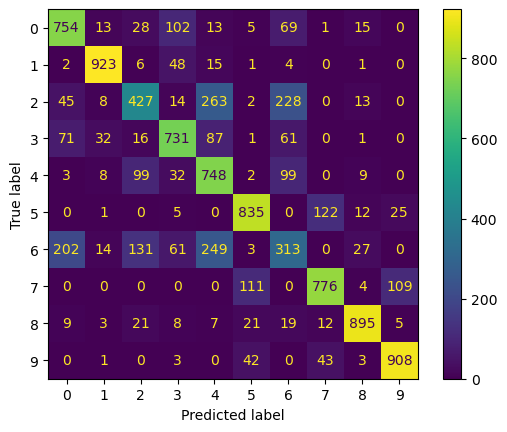

              precision    recall  f1-score   support

           0       0.69      0.75      0.72      1000
           1       0.92      0.92      0.92      1000
           2       0.59      0.43      0.49      1000
           3       0.73      0.73      0.73      1000
           4       0.54      0.75      0.63      1000
           5       0.82      0.83      0.83      1000
           6       0.39      0.31      0.35      1000
           7       0.81      0.78      0.79      1000
           8       0.91      0.90      0.90      1000
           9       0.87      0.91      0.89      1000

    accuracy                           0.73     10000
   macro avg       0.73      0.73      0.73     10000
weighted avg       0.73      0.73      0.73     10000



In [35]:
plot_cm_display(y_test, y_pred)
print(classification_report(y_test, y_pred))

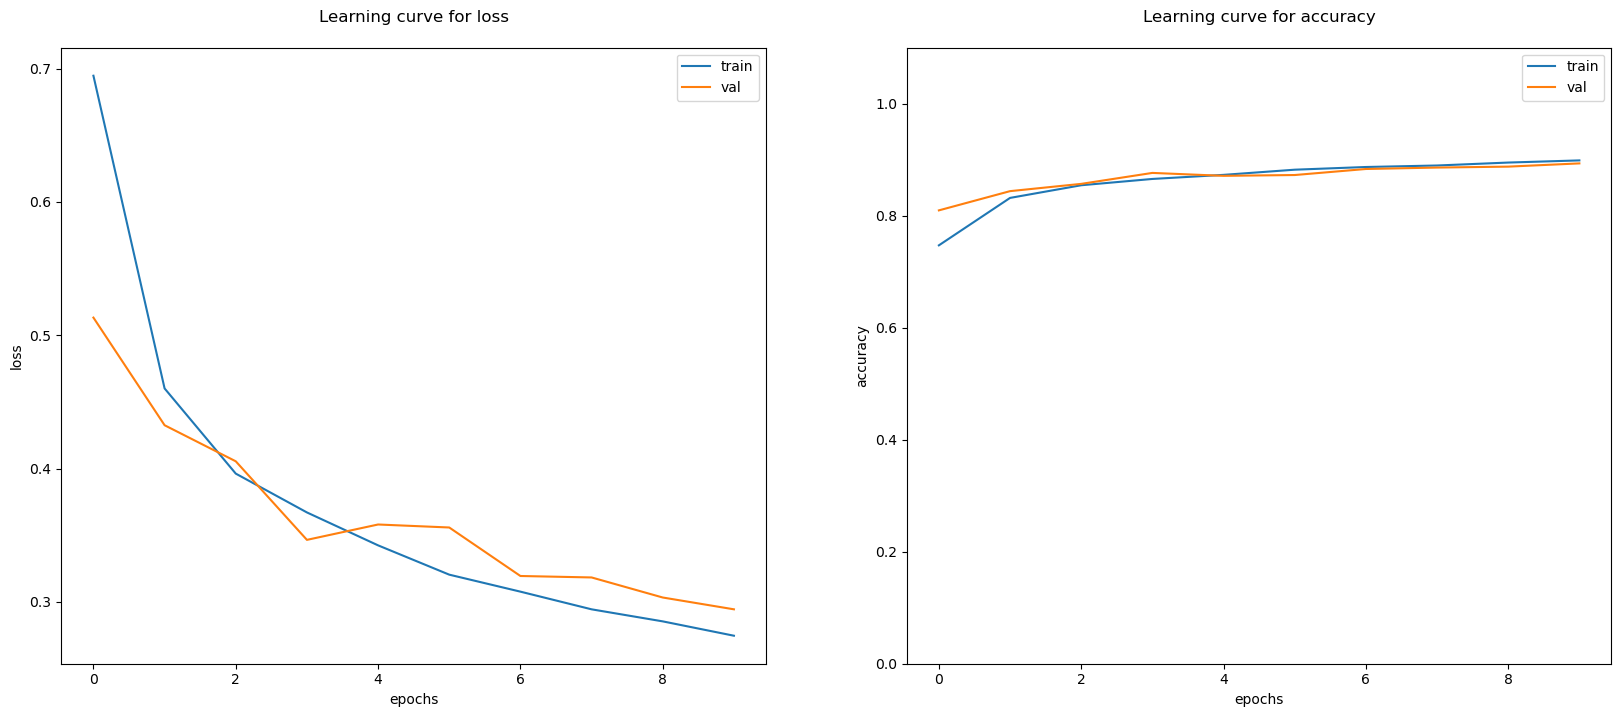

In [44]:
plot_lc(cnn_2.history.history)

In [23]:
y_pred_2 = np.argmax(cnn_2.predict(X_test), axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


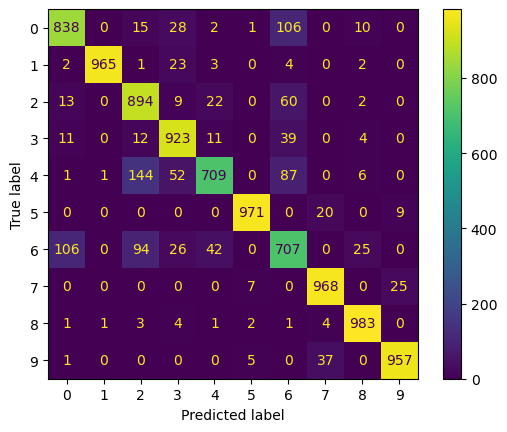

              precision    recall  f1-score   support

           0       0.86      0.84      0.85      1000
           1       1.00      0.96      0.98      1000
           2       0.77      0.89      0.83      1000
           3       0.87      0.92      0.89      1000
           4       0.90      0.71      0.79      1000
           5       0.98      0.97      0.98      1000
           6       0.70      0.71      0.71      1000
           7       0.94      0.97      0.95      1000
           8       0.95      0.98      0.97      1000
           9       0.97      0.96      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [45]:
plot_cm_display(y_test, y_pred_2)
print(classification_report(y_test, y_pred_2))

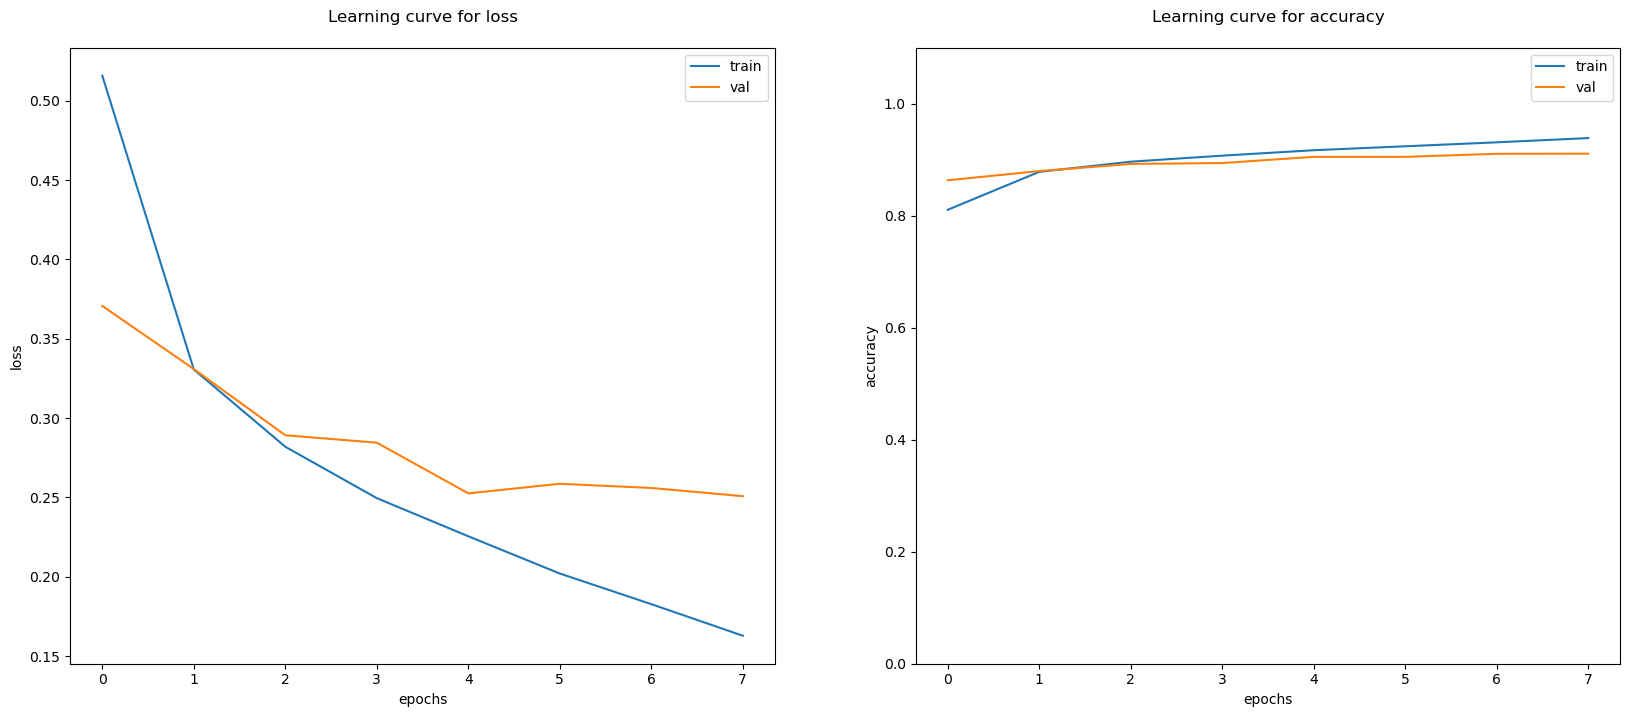

In [21]:
plot_lc(cnn_3.history.history)

In [24]:
y_pred_3 = np.argmax(cnn_3.predict(X_test), axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


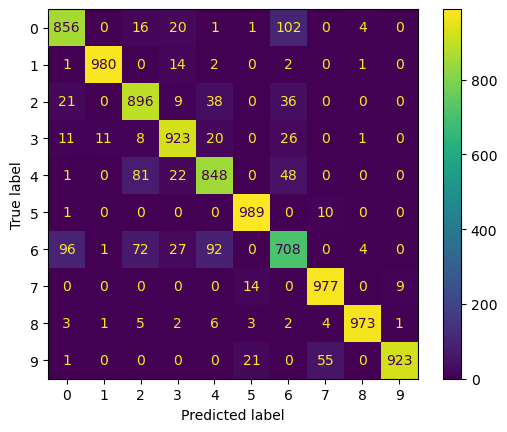

              precision    recall  f1-score   support

           0       0.86      0.86      0.86      1000
           1       0.99      0.98      0.98      1000
           2       0.83      0.90      0.86      1000
           3       0.91      0.92      0.92      1000
           4       0.84      0.85      0.85      1000
           5       0.96      0.99      0.98      1000
           6       0.77      0.71      0.74      1000
           7       0.93      0.98      0.96      1000
           8       0.99      0.97      0.98      1000
           9       0.99      0.92      0.95      1000

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



In [28]:
plot_cm_display(y_test, y_pred_3)
print(classification_report(y_test, y_pred_3))

### Model definition using Functional API

In [59]:
inputs = keras.Input(shape=(28, 28, 1))
x = Reshape((28, 28, 1))(inputs)

# --- Augmentation -->
x = Rescaling(1./255)(x)
x = RandomRotation(0.05)(x)
x = RandomFlip("horizontal")(x)

# --- CNN -->
x = Convolution2D(32, 3, activation='relu')(x)
x = MaxPooling2D()(x)
x = Convolution2D(64, 3, activation='relu')(x)
x = MaxPooling2D()(x)
x = Flatten()(x)
x = Dense(128, activation='relu')(x)

outputs = Dense(10, activation="softmax")(x)

model = keras.Model(inputs=inputs, outputs=x)

model.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_15 (InputLayer)     │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_11 (Reshape)            │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_8 (Rescaling)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_7               │ (None, 28, 28, 1)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_7 (RandomFlip)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 128)            │       204,928 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 223,744 (874.00 KB)

 Trainable params: 223,744 (874.00 KB)

 Non-trainable params: 0 (0.00 B)